# ANN 기반 기대수명 예측

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('저장소 루트 또는 notebooks 폴더에서 실행하세요.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.train import load_data, clean_data, prepare_data, run_experiment, FEATURES, TARGET
from src.model import LifeExpectancyANN
pd.set_option('display.max_columns', 20)
from src.anova import run_anova, CANDIDATES

## 1. 데이터

In [2]:
raw = load_data()
print(f'Rows: {len(raw)}, countries: {raw.Country.nunique()}')
display(raw[['Country', 'Year', TARGET]].head())
display(raw[[TARGET, *FEATURES]].describe().T[['count', 'mean', 'std', 'min', 'max']].round(2))

Rows: 2938, countries: 193


,Country,Year,Life expectancy
0,Afghanistan,2015,65.0
1,Afghanistan,2014,59.9
2,Afghanistan,2013,59.9
3,Afghanistan,2012,59.5
4,Afghanistan,2011,59.2


,count,mean,std,min,max
Life expectancy,2928.0,69.22,9.52,36.30,89.00
Adult Mortality,2928.0,164.80,124.29,1.00,723.00
infant deaths,2938.0,30.30,117.93,0.00,1800.00
Alcohol,2744.0,4.60,4.05,0.01,17.87
percentage expenditure,2938.0,738.25,1987.91,0.00,19479.91
Hepatitis B,2385.0,80.94,25.07,1.00,99.00
BMI,2904.0,38.32,20.04,1.00,87.30
under-five deaths,2938.0,42.04,160.45,0.00,2500.00
Polio,2919.0,82.55,23.43,3.00,99.00
Diphtheria,2919.0,82.32,23.72,2.00,99.00


## 2. 분산분석

In [3]:
anova_table, anova_rows = run_anova(raw)
print(f'ANOVA observations: {anova_rows}')
ann_input = pd.Series({name: name in FEATURES for name in CANDIDATES})
display(anova_table.assign(ann_input=ann_input))
(ROOT / 'results').mkdir(exist_ok=True)
anova_table.to_csv(ROOT / 'results/anova.csv')

ANOVA observations: 1649


,df,sum_sq,mean_sq,F,p_value,ann_input
variable,,,,,,
Adult Mortality,1.0,62940.644498,62940.644498,4867.825139,0.000000e+00,True
infant deaths,1.0,2477.383847,2477.383847,191.600697,2.793350e-41,True
Alcohol,1.0,9378.516630,9378.516630,725.333835,1.824210e-132,True
percentage expenditure,1.0,2695.705875,2695.705875,208.485708,1.459495e-44,True
Hepatitis B,1.0,965.601922,965.601922,74.679587,1.298440e-17,True
Measles,1.0,6.770944,6.770944,0.523664,4.693866e-01,False
BMI,1.0,5548.672675,5548.672675,429.133965,8.227488e-85,True
under-five deaths,1.0,2949.306857,2949.306857,228.099191,2.461046e-48,True
Polio,1.0,576.115885,576.115885,44.556763,3.377000e-11,True


## 3. 결측치

In [4]:
missing = raw[[TARGET, *FEATURES]].isna().sum().rename('missing_rows')
display(missing.to_frame())
clean = clean_data(raw)
print(f'Removed: {len(raw) - len(clean)}, remaining: {len(clean)} rows')
print(f'Countries: {clean.Country.nunique()}, input features: {len(FEATURES)}')

,missing_rows
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
BMI,34
under-five deaths,0
Polio,19
Diphtheria,19


Removed: 1083, remaining: 1855 rows
Countries: 147, input features: 14


## 4. 데이터 분할 및 정규화

In [5]:
data = prepare_data(clean)
frames = data['frames']
display(pd.DataFrame({
    name: {'rows': len(frame), 'countries': frame.Country.nunique()}
    for name, frame in frames.items()
}).T)
shared = set(frames['train'].Country) & set(frames['test'].Country)
print(f'Countries shared by train and test: {len(shared)}')

,rows,countries
train,1113,146
validation,371,134
test,371,134


Countries shared by train and test: 133


## 5. ANN

In [6]:
example_model = LifeExpectancyANN(n_features=len(FEATURES), hidden_nodes=10)
print(example_model)
print('Trainable parameters:', sum(p.numel() for p in example_model.parameters()))

LifeExpectancyANN(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=10, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
)
Trainable parameters: 161


## 6. 학습 및 모델 비교

In [7]:
result = run_experiment(data, output_dir=ROOT / 'results')
display(result['validation'].round(4))

,hidden_nodes,best_epoch,epochs_run,mae_years,rmse_years,r2,pearson_r,selected
0,5,4000,4000,2.3253,3.0820,0.8646,0.9303,False
1,10,4000,4000,1.6338,2.2686,0.9266,0.9629,True
2,15,3997,4000,1.7671,2.4218,0.9164,0.9578,False


## 7. 학습 곡선

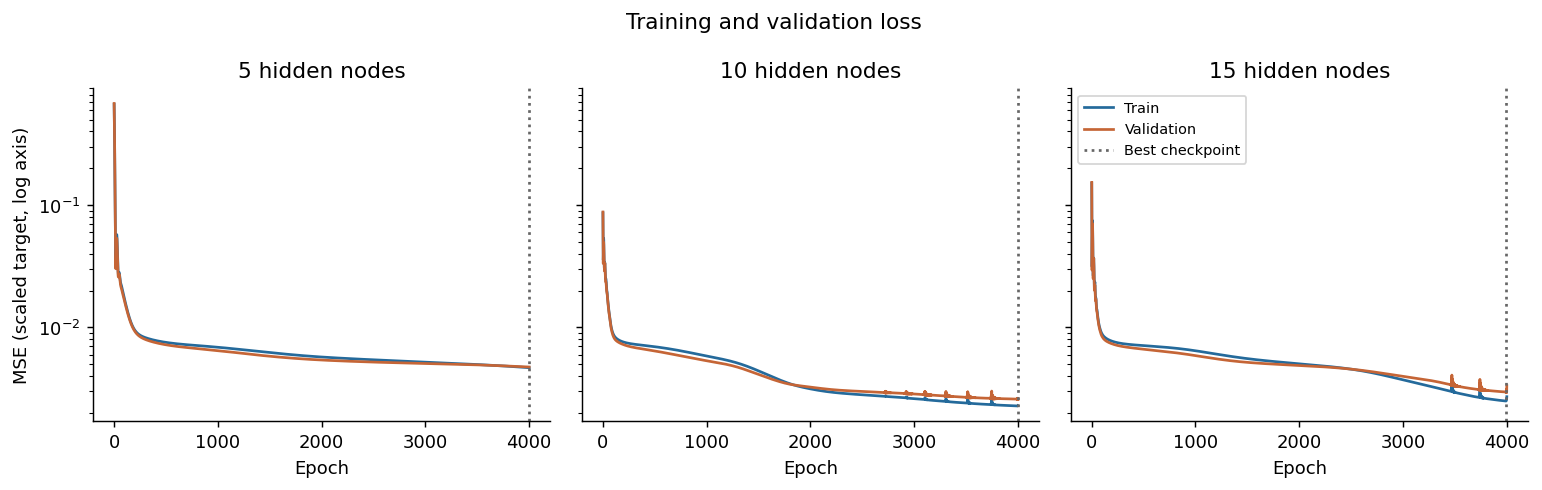

In [8]:
display(Image(filename=str(ROOT / 'results/figures/learning_curves.png')))

## 8. 평가

,model,split,mae_years,rmse_years,r2,pearson_r
0,ANN (10 nodes),test,1.8111,2.5318,0.9123,0.9574
1,Linear regression,test,2.7494,3.6897,0.8137,0.9028


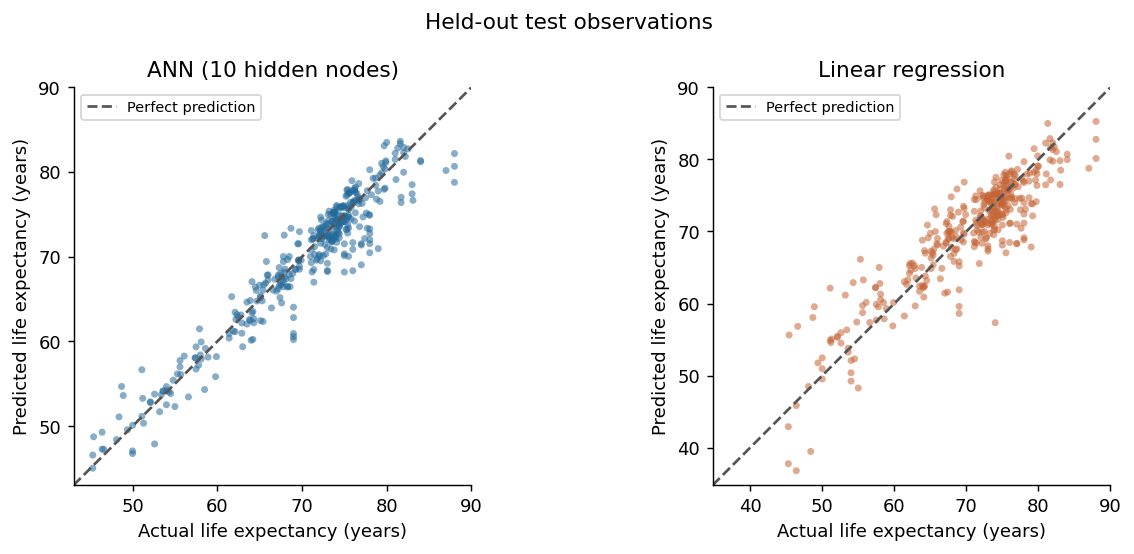

In [9]:
display(result['metrics'].round(4))
display(Image(filename=str(ROOT / 'results/figures/predictions.png')))